# Natural Gas Data Visualization - Henry Hub

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "font.family": "serif", "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.30, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})

For this part, we analyse the natural gas data: we look for potential trends and decide which model to use first.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.filters.hp_filter import hpfilter

## Data Import & First Look

In [3]:
df_natgas = pd.read_csv('/Users/nayelbenabdesadok/GitProjects/Weather Derivatives/data/Henry_Hub_Natural_Gas_Spot_Price.csv')

In [4]:
df_natgas['Day'] = pd.to_datetime(df_natgas['Day'])
df_natgas = df_natgas.sort_values(by='Day', ascending=True)
df_natgas = df_natgas.reset_index(drop=True)
df_natgas['t'] = df_natgas.index
df_natgas = df_natgas.rename(columns={"Henry Hub Natural Gas Spot Price Dollars per Million Btu": "price"})
df_natgas.set_index('Day', inplace=True)
df_natgas.head()

,price,t,return,log_return
Day,,,,
1997-01-09,3.61,0,-0.050000,-0.051293
1997-01-10,3.92,1,0.085873,0.082384
1997-01-13,4.00,2,0.020408,0.020203
1997-01-14,4.01,3,0.002500,0.002497
1997-01-15,4.34,4,0.082294,0.079083


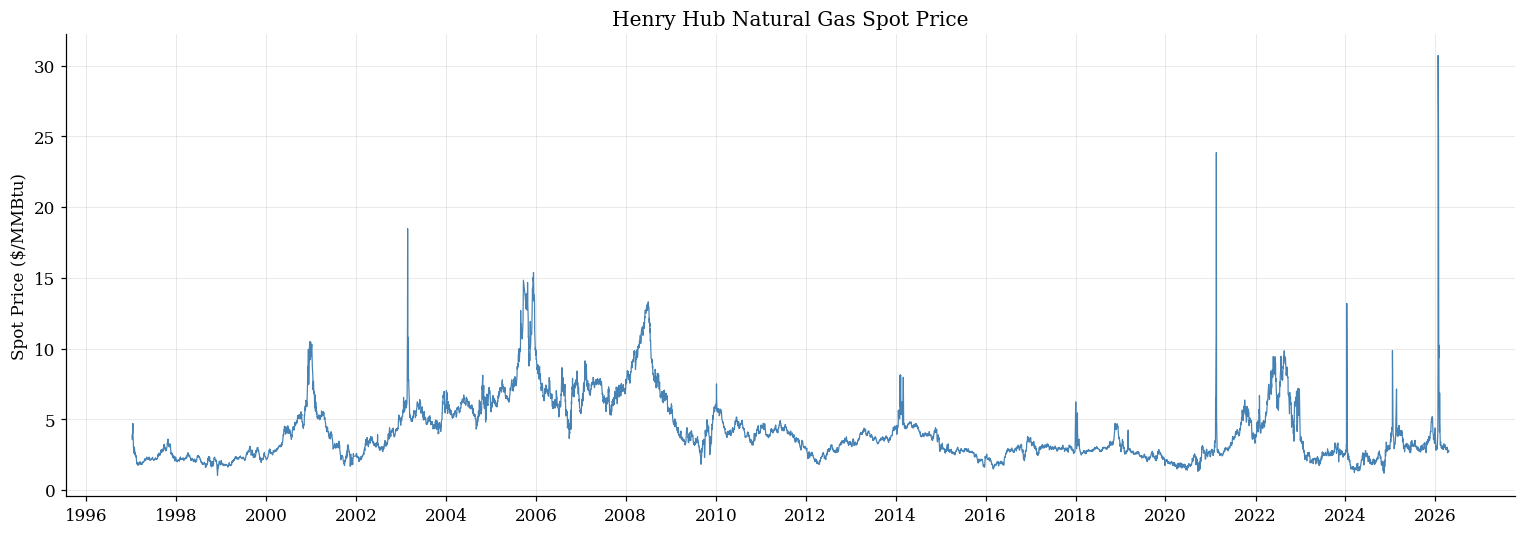

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_natgas.index, df_natgas['price'], color='steelblue', lw=0.8, alpha=1)
ax.set_ylabel("Spot Price ($/MMBtu)")
ax.set_title("Henry Hub Natural Gas Spot Price")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.grid(True)
plt.show()

A few preliminary observations:

- The unit of the series is \$/MMBtu (Million British Thermal Units): 1 BTU is the energy needed to heat 1 pound of water by 1°F. It is the standard selling unit for natural gas, as gas is priced on the energy value it delivers rather than on its raw volume.

- We clearly distinguish two coexisting dynamics on the series. On one hand, a long-term level slowly oscillating around an equilibrium price between 3 and 5 \$/MMBtu over the whole period. On the other hand, violent and transitory short-term deviations around this level, with a quick mean reversion after each shock.

- These deviations take the form of asymmetric upward spikes, systematically triggered by major weather or geopolitical events: cold winter and low storage in 2003, hurricanes Katrina and Rita in 2005, the Texas Freeze in February 2021, or the surge in LNG export demand to Europe following the Russia-Ukraine conflict in 2022.

- Finally, the **volatility is heteroskedastic**: particularly high between 2005 and 2008 and between 2021 and 2023, it is on the contrary remarkably low over 2012-2020.

## Literature Overview: the Schwartz-Smith 2 factors model

The literature on the natural gas market informs us about the main commodity models. One of the most relevant here is the two-factor model of Schwartz & Smith (2000), which complements the one-factor model of Schwartz (1997). In the latter, the spot log-price of a commodity decomposes into two additive factors:

$$\ln(S_t) = \chi_t + \xi_t$$

- a short-term factor $\chi_t$: an Ornstein-Uhlenbeck process mean-reverting to 0, with high volatility and a fast mean-reversion speed. It captures the intense spikes observed on the series (weather or geopolitical shocks) as well as their quick resorption.

- a long-term factor $\xi_t$: also a mean-reverting process, but toward an equilibrium level $\mu_\xi / \gamma$, with low volatility and a very slow mean-reversion speed, to the point of resembling a random walk over short horizons.

The log transformation is justified by two arguments: it guarantees price positivity by construction ($S_t = \exp(\chi_t + \xi_t) > 0$), and it turns the multiplicative shocks observed on $S_t$ into additive shocks on $\ln(S_t)$, consistent with the additive structure of the model.

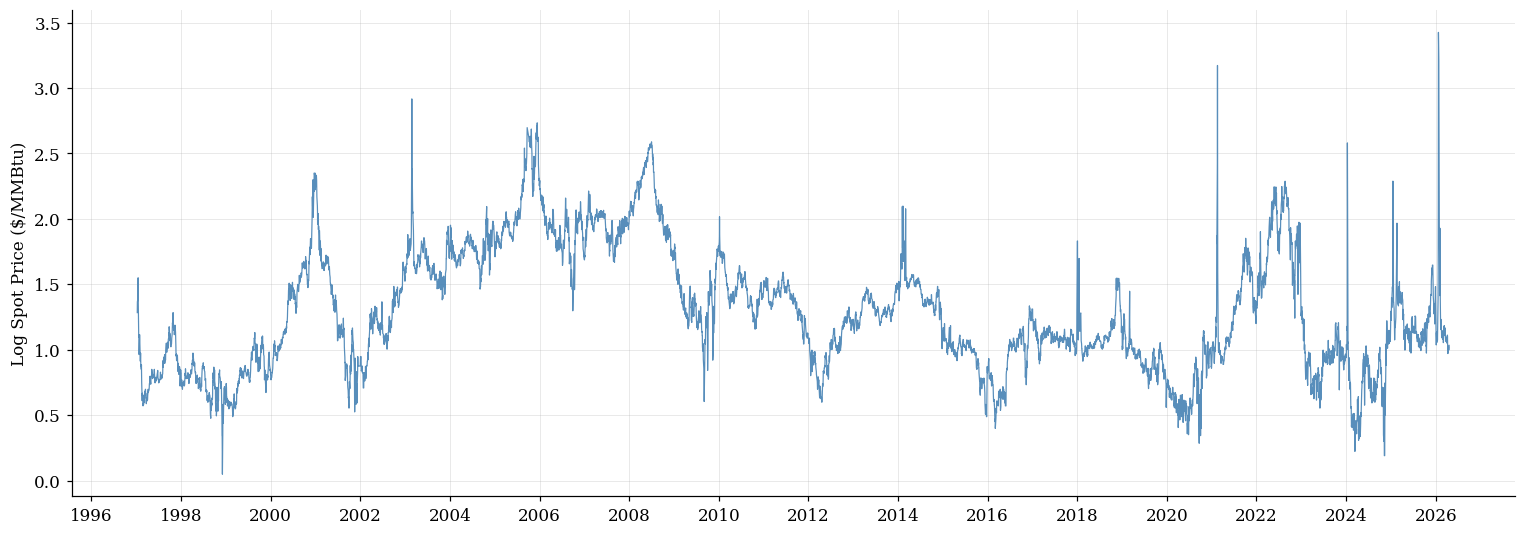

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_natgas.index, np.log(df_natgas['price']), color='steelblue', lw=0.8, alpha=0.9)
ax.set_ylabel("Log Spot Price ($/MMBtu)")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.show()

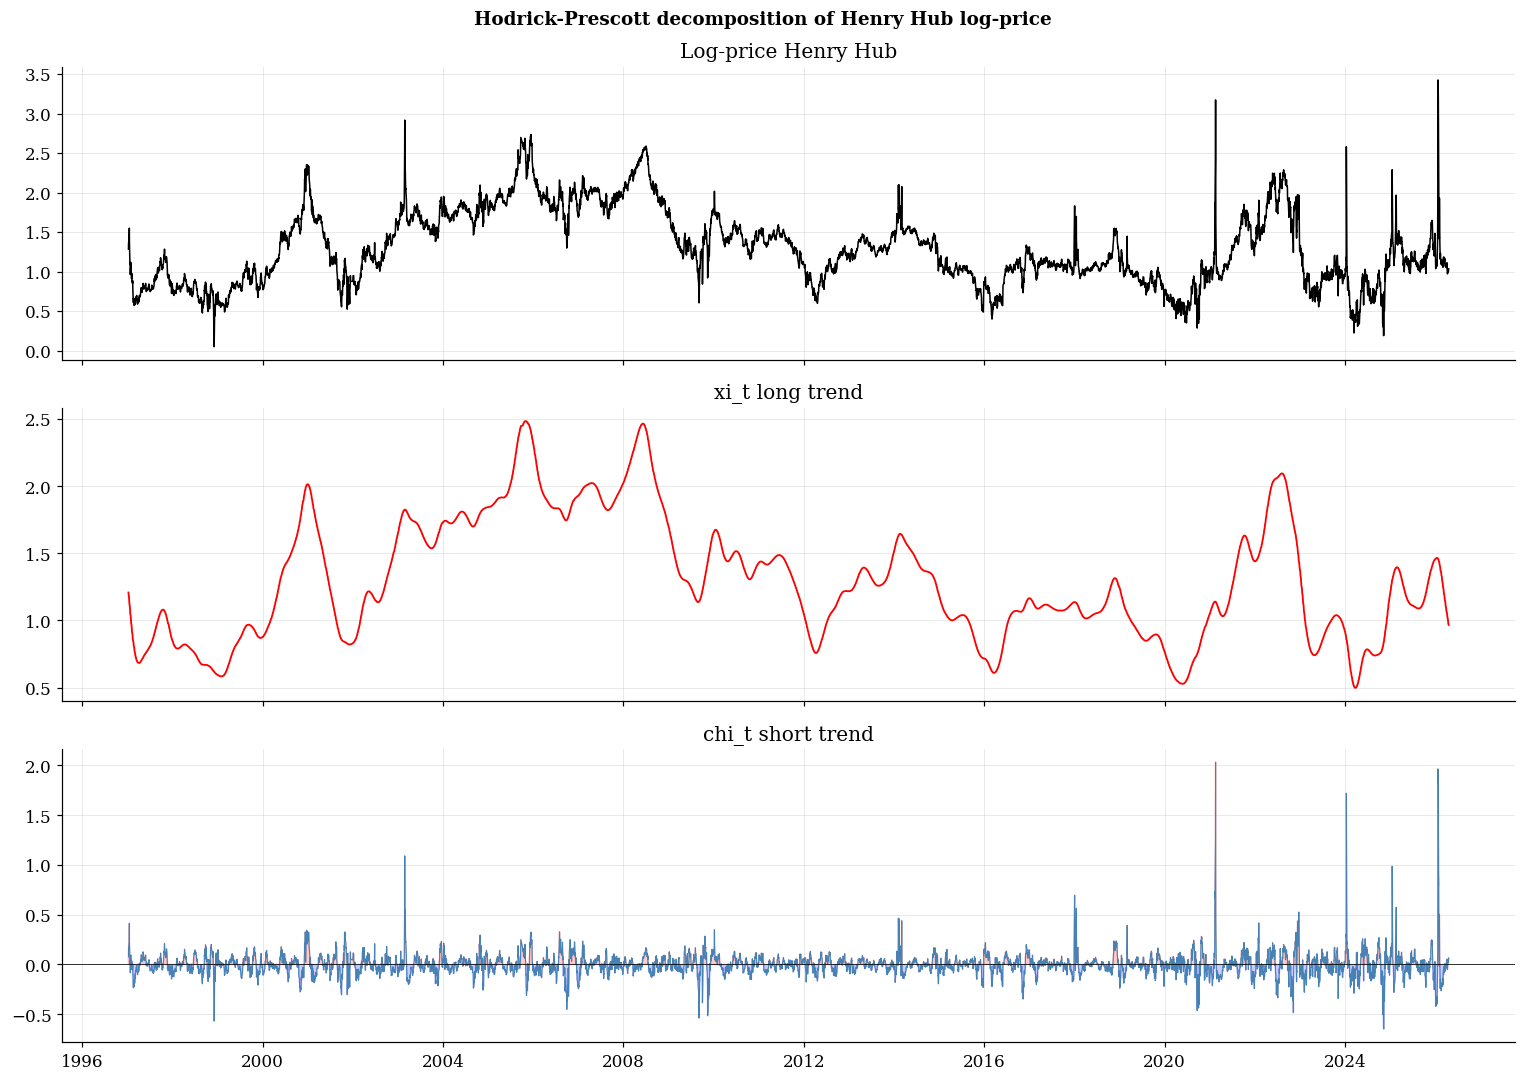

In [7]:
df = df_natgas.copy()
df["log_price"] = np.log(df["price"])

# lambda=129600 is the convention for daily data
cycle, trend = hpfilter(df['log_price'], lamb=129600)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Hodrick-Prescott decomposition of Henry Hub log-price", fontsize=12, fontweight='bold')

axes[0].plot(df.index, df['log_price'], color='black', lw=1.0)
axes[0].set_title("Log-price Henry Hub")

axes[1].plot(df.index, trend, color='red', lw=1.2)
axes[1].set_title("xi_t long trend")

axes[2].plot(df.index, cycle, color='steelblue', lw=0.7)
axes[2].axhline(0, color='black', lw=0.5)
axes[2].fill_between(df.index, cycle, 0,
                     where=cycle > 0, alpha=0.2, color='red')
axes[2].fill_between(df.index, cycle, 0,
                     where=cycle < 0, alpha=0.2, color='blue')
axes[2].set_title("chi_t short trend")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

In our case, the goal is to identify the two dynamics $\xi_t$ and $\chi_t$, and in particular the short-term factor $\chi_t$. Indeed, pricing weather derivatives reduces to computing an expectation under $\mathbb{Q}$ of a payoff whose value depends on the distribution of future realizations of the gas price, and it is volatility that shapes this distribution, especially in the tails.

The central idea is therefore to model the short-term volatility $\sigma_{\chi_t}$ conditionally on temperature anomalies:

$$\sigma_{\chi_t} = f\left(\widetilde{HDD}_t\right)$$

What we therefore need to do:
1. Extract the latent states $\hat{\chi}_t$ and $\hat{\xi}_t$, which are not directly observable on the market.
2. Estimate the model parameters on historical data.

These steps are detailed in the following notebooks, where we apply a Kalman filter to try to solve the problem.